# Notebook 3: where does RL-DOHO work best? Feature-count sweep on RA whole-blood gene expression (GSE93272)

**Hypothesis (stated before running):** RL-DOHO's local search flips 1–3 features at a time. That move matters most when the number of candidate features is moderate (hundreds to about 2,000), and matters less with many thousands, where HO's larger moves can do better.
Across Notebooks 1–2 RL-DOHO was 1st on the 14-feature clinical data and on Colon (2,000 genes), but 2nd on ALL/AML (7,129 genes).

**Test:** the same patients and the same disease (rheumatoid arthritis vs healthy, GEO GSE93272). Only the number of candidate features changes: the **200 / 500 / 1,000 / 2,000 / 5,000** most variable probes, chosen on each training split only.
All five sizes are reported, whatever the outcome.

**Robustness check, batch 1 only:** batch 2 is 88% RA, so a classifier could partly learn batch rather than disease. Batch 1 is balanced (30 RA / 30 healthy), and the whole sweep is repeated on batch 1 alone.

**Settings** (each one is treated as a dataset below):
- `all_N200` … `all_N5000`: all 101 people (one sample per person).
- `b1_N200` … `b1_N5000`: batch 1 only (60 people).

**Unchanged from Notebook 3:**
- **Algorithms:** DO, HO, DOHO and RL-DOHO, identical code to Notebooks 1–2.
- **Fitness:** KNN balanced accuracy, 70/30 splits, 10 seeds, 20 agents × 50 iterations.
- **Statistics and ablation:** as in Notebook 3.

**Section 12** plots each algorithm's average rank against the number of features. That's the answer to "where is RL-DOHO best suited?".

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, balanced_accuracy_score
from scipy.stats import wilcoxon, friedmanchisquare
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
OUT_DIR  = '/content/drive/MyDrive/rl_doho_results_ra_sweep' if IN_COLAB else 'rl_doho_results_ra_sweep'
DATA_DIR = f"{OUT_DIR}/data"
SIZES    = [200, 500, 1000, 2000, 5000]   # candidate features (most variable probes, training split only)
DATASETS = [f"all_N{n}" for n in SIZES] + [f"b1_N{n}" for n in SIZES]
SCORING  = "balanced_accuracy"
SEEDS    = list(range(10))
POP_SIZE, MAX_ITER = 20, 50
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01

# RL-DOHO settings: identical to Notebook 1
STAG_TRIGGER, UCB_C, TABU_TENURE, TIE_EPS = 2, 1.0, None, 0.001

DETAIL_DATASET, DETAIL_SEED = "all_N1000", 0   # section 7: one run per algorithm with every iteration printed
VERBOSE      = False                       # True prints every iteration of every benchmark run (very long)
RUN_ABLATION = True

os.makedirs(DATA_DIR, exist_ok=True)
ALGOS = ["DO", "HO", "DOHO", "RL-DOHO"]; PROPOSED = "RL-DOHO"
COLORS = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR)

Output folder: /content/drive/MyDrive/rl_doho_results_ra_sweep


## 3. Data: download GSE93272 from GEO once, keep one sample per person, check batches

In [3]:
import gzip
GEO_URL = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE93nnn/GSE93272/matrix/GSE93272_series_matrix.txt.gz"
path = f"{DATA_DIR}/GSE93272_series_matrix.txt.gz"
if not os.path.exists(path):
    print("downloading (about 80 MB)...")
    urllib.request.urlretrieve(GEO_URL, path)

titles, chars = None, []
with gzip.open(path, "rt") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"):
            gsm = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
        elif line.startswith("!Sample_characteristics_ch1"):
            chars.append([v.strip('"') for v in line.rstrip("\n").split("\t")[1:]])
        elif line.startswith("!series_matrix_table_begin"):
            break
    expr = pd.read_csv(f, sep="\t", index_col=0, comment="!")

# Characteristics rows look like "key: value"; turn them into one table with a column per key
meta = pd.DataFrame(index=gsm)
for row in chars:
    keys = {v.split(":", 1)[0].strip() for v in row if ":" in v}
    if len(keys) == 1:
        k = keys.pop(); meta[k] = [v.split(":", 1)[1].strip() if ":" in v else None for v in row]
expr = expr[gsm]
print("expression matrix:", expr.shape, "(probes x samples)")
print("all samples:", meta["disease state"].value_counts().to_dict())

# One sample per person: keep the first sample of each individual
meta["individual id"] = meta.get("individual id", pd.Series(meta.index, index=meta.index)).fillna(pd.Series(meta.index, index=meta.index))
keep = ~meta["individual id"].duplicated(keep="first")
meta_k = meta[keep]
print(f"one sample per person: {keep.sum()} of {len(meta)} samples kept")
print("after de-duplication:", meta_k["disease state"].value_counts().to_dict())

print("\nBatch x disease (check: healthy and RA should not be split by batch):")
ct = pd.crosstab(meta_k["batch"], meta_k["disease state"]); print(ct)
X_all = expr[meta_k.index].T.values.astype(float)
y_all = (meta_k["disease state"].str.upper() == "RA").astype(int).values     # 1 = RA, 0 = healthy
b1 = (meta_k["batch"].astype(str) == "1").values
BASE = {"all": (X_all, y_all), "b1": (X_all[b1], y_all[b1])}
DATA = {ds: BASE[ds.split("_")[0]] for ds in DATASETS}
for k, (Xk, yk) in BASE.items():
    print(f"{k:3s}: {Xk.shape[0]} people x {Xk.shape[1]} probes;  RA={yk.sum()}, healthy={(1 - yk).sum()}")
print("value range:", round(float(np.nanmin(X_all)), 2), "to", round(float(np.nanmax(X_all)), 2), "(log2 scale)")

downloading (about 80 MB)...
expression matrix: (54613, 275) (probes x samples)
all samples: {'RA': 232, 'healthy control': 43}
one sample per person: 101 of 275 samples kept
after de-duplication: {'RA': 66, 'healthy control': 35}

Batch x disease (check: healthy and RA should not be split by batch):
disease state  RA  healthy control
batch                             
1              30               30
2              36                5
all: 101 people x 54613 probes;  RA=66, healthy=35
b1 : 60 people x 54613 probes;  RA=30, healthy=30
value range: 2.6 to 14.46 (log2 scale)


## 4. Fitness function (KNN, balanced accuracy, CV on the training part only) and test evaluation

In [4]:
COUNTER = {"calls": 0, "new": 0}
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()   # compact key for long masks

def use_dataset(name, seed):
    # Set the active dataset and split. Each (dataset, seed) has its own split, scaler and fitness cache.
    global X_tr, X_te, y_tr, y_te, N_FEATURES, FEATURES, _cache, CV, CUR
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    col_mean = np.nanmean(X_tr, axis=0)                      # fill any missing values with training means
    X_tr = np.where(np.isnan(X_tr), col_mean, X_tr); X_te = np.where(np.isnan(X_te), col_mean, X_te)
    n_top = int(name.split('_N')[1])
    top = np.argsort(X_tr.var(axis=0))[-n_top:]              # most variable probes, training part only
    X_tr, X_te = X_tr[:, top], X_te[:, top]
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X_tr.shape[1]; FEATURES = [f"p{i}" for i in top]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed)
    CUR = (name, seed)
    cf = f"{OUT_DIR}/cache_{name}_s{seed}.pkl"
    _cache = pickle.load(open(cf, "rb")) if os.path.exists(cf) else {}

def save_cache(): pass                     # called by the logger; the cache is saved once per (dataset, seed) instead
def save_cache_now(): pickle.dump(_cache, open(f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl", "wb"))

def fitness_function(mask, X_=None, y_=None):
    COUNTER["calls"] += 1
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV, scoring=SCORING).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}; COUNTER["new"] += 1
    return f

def evaluate_on_test(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    return {"acc": float(balanced_accuracy_score(y_te, p)), "plain_acc": float(np.mean(p == y_te)),
            "f1": float(f1_score(y_te, p, average="macro")), "pred": p}

for name in DATASETS:
    use_dataset(name, 0)
    t = time.time(); fa = fitness_function(np.ones(N_FEATURES, int))
    print(f"{name}: one fitness evaluation {time.time()-t:.2f}s | all {N_FEATURES} probes: CV balanced acc="
          f"{_cache[mask_str(np.ones(N_FEATURES, int))]['acc']:.3f}, test balanced acc={evaluate_on_test(np.ones(N_FEATURES, int))['acc']:.3f}"
          f"  (train {len(y_tr)}: RA={y_tr.sum()}, healthy={(1-y_tr).sum()} | test {len(y_te)}: RA={y_te.sum()}, healthy={(1-y_te).sum()})")

all_N200: one fitness evaluation 0.05s | all 200 probes: CV balanced acc=0.772, test balanced acc=0.809  (train 70: RA=46, healthy=24 | test 31: RA=20, healthy=11)
all_N500: one fitness evaluation 0.02s | all 500 probes: CV balanced acc=0.763, test balanced acc=0.805  (train 70: RA=46, healthy=24 | test 31: RA=20, healthy=11)
all_N1000: one fitness evaluation 0.02s | all 1000 probes: CV balanced acc=0.798, test balanced acc=0.784  (train 70: RA=46, healthy=24 | test 31: RA=20, healthy=11)
all_N2000: one fitness evaluation 0.02s | all 2000 probes: CV balanced acc=0.846, test balanced acc=0.805  (train 70: RA=46, healthy=24 | test 31: RA=20, healthy=11)
all_N5000: one fitness evaluation 0.03s | all 5000 probes: CV balanced acc=0.864, test balanced acc=0.875  (train 70: RA=46, healthy=24 | test 31: RA=20, healthy=11)
b1_N200: one fitness evaluation 0.01s | all 200 probes: CV balanced acc=0.785, test balanced acc=0.889  (train 42: RA=21, healthy=21 | test 18: RA=9, healthy=9)
b1_N500: one 

## 5. Shared helpers: binarization and the per-iteration logger (same as Notebook 1)

In [5]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def binarize(position): return (sigmoid(position) > 0.5).astype(int)
def mask_disp(m):   # bit string for small problems, a count for high-dimensional ones
    return mask_str(m) if N_FEATURES <= 40 else f"{int(np.sum(m))}/{N_FEATURES} selected"

class IterLogger:
    # Records and prints every iteration of a run.
    def __init__(self, algo, seed, verbose=True):
        self.algo, self.seed, self.verbose = algo, seed, verbose
        self.rows, self.t0, self.seen = [], time.time(), set()
        if verbose:
            print(f"\n{'='*118}\n{algo}  | seed={seed} | pop={POP_SIZE} | iters={MAX_ITER}\n{'='*118}")
            print(f"{'iter':>4} | {'action':<14}| {'best':>7} {'genbest':>7} {'mean':>7} {'worst':>7} | "
                  f"{'#f':>5} | {'best mask':<{min(N_FEATURES, 40) if N_FEATURES <= 40 else 18}} | {'div':>5} | {'new':>3} | {'sec':>5}")

    def log(self, t, action, positions, fitness, best_fit, best_mask, reward=None):
        pm = np.array([binarize(p) for p in positions])
        fresh = {mask_str(m) for m in pm} - self.seen; new = len(fresh); self.seen |= fresh
        row = dict(iter=t, action=action, best=best_fit, gen_best=float(np.min(fitness)),
                   mean=float(np.mean(fitness)), worst=float(np.max(fitness)),
                   n_feats=int(best_mask.sum()), best_mask=best_mask.copy() if N_FEATURES <= 40 else None,
                   pop_masks=pm if N_FEATURES <= 40 else None,
                   diversity=float(np.mean(np.std(positions, axis=0))), new_evals=new,
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = f" r={reward:+.3f}" if reward is not None else ""
            print(f"{t:>4} | {action:<14}| {row['best']:.4f} {row['gen_best']:.4f} {row['mean']:.4f} {row['worst']:.4f} | "
                  f"{row['n_feats']:>5} | {mask_disp(best_mask)} | {row['diversity']:.3f} | {new:>3} | {row['sec']:5.1f}{rw}")
        self.t0 = time.time()

    def finish(self, best_fit, best_mask):
        if self.verbose:
            sel = [FEATURES[i] for i in np.flatnonzero(best_mask)]
            print(f"    ('new' = subsets this run had not evaluated before; {len(self.seen)} distinct subsets in total)")
            print(f"--> {self.algo} done: best fitness={best_fit:.4f}, CV acc={_cache[mask_str(best_mask)]['acc']:.4f}, "
                  f"{len(sel)} features" + (f": {sel}" if len(sel) <= 15 else f" (first 10: {sel[:10]})"))
        save_cache()
        return pd.DataFrame(self.rows)

## 6. The algorithms (identical code to Notebook 1)

In [6]:
def _init(rng, dim):
    positions = rng.uniform(-1, 1, size=(POP_SIZE, dim))
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    b = np.argmin(fitness)
    return positions, masks, fitness, positions[b].copy(), masks[b].copy(), fitness[b]

def _evaluate_and_update(positions, fitness, best_position, best_mask, best_fitness, t):
    # Elitism (worst of previous generation gets the best), evaluate, update the global best.
    worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1
    positions[worst_idx] = best_position.copy()
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    g = np.argmin(fitness); improved = fitness[g] < best_fitness
    if improved:
        best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
    return masks, fitness, best_position, best_mask, best_fitness, improved

# ---------------- DO ----------------
def dandelion_optimizer(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "rising" if progress < 0.4 else ("descending" if progress < 0.8 else "landing")
        for i in range(POP_SIZE):
            if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
            elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:                positions[i] += rng.normal(0, 0.1, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, phase, positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- HO ----------------
def hippopotamus_optimization(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("HO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        n_mv = [0, 0, 0]
        for i in range(POP_SIZE):
            r = rng.random()
            if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6; n_mv[0] += 1
            elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i]); n_mv[1] += 1
            else:         positions[i] += rng.normal(0, 0.6, dim); n_mv[2] += 1
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"mv{n_mv[0]}/df{n_mv[1]}/ev{n_mv[2]}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- Fixed DOHO ----------------
def doho_fixed(seed=42, verbose=True, switch_point=0.5):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DOHO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "DO" if progress <= switch_point else "HO"
        for i in range(POP_SIZE):
            if phase == "DO":
                if progress < switch_point * 0.6: positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                else: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"phase {phase}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

In [7]:
# ---------------- Previous RL-DOHO (Q-learning controller, v10): used only in the ablation ----------------
ACTION_NAMES = {0: "DO", 1: "HO", 2: "PERTURB", 3: "RESTART"}

class QLearningController:
    def __init__(self, n_actions=4, alpha=0.5, gamma=0.5, epsilon=0.3, epsilon_decay=0.85, seed=42):
        self.rng = np.random.default_rng(seed); self.q_table = {}
        self.alpha, self.gamma, self.epsilon, self.epsilon_decay, self.n_actions = alpha, gamma, epsilon, epsilon_decay, n_actions
    def get_state(self, positions, stagnation, progress):
        div = np.mean(np.std(positions, axis=0))
        return (int(div >= 0.8), int(stagnation >= 3), int(progress >= 0.5))
    def _q(self, s):
        if s not in self.q_table: self.q_table[s] = np.zeros(self.n_actions)
        return self.q_table[s]
    def choose_action(self, state):
        q = self._q(state)
        if self.rng.random() < self.epsilon: return int(self.rng.integers(0, self.n_actions)), "explore"
        best = np.flatnonzero(q == q.max())                 # random tie-break, not always action 0
        return int(self.rng.choice(best)), "greedy"
    def update(self, s, a, r, s2):
        q = self._q(s); q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])
    def decay_epsilon(self): self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

def rl_doho_qlearning(seed=42, verbose=True, perturb_frac=0.15, controller=None, name="RL-DOHO (Q-learning)"):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = controller(seed) if controller else QLearningController(seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    stagnation = 0; k = max(1, int(round(dim * perturb_frac)))
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        state = agent.get_state(positions, stagnation, progress)
        action, how = agent.choose_action(state)
        order = np.argsort(fitness); worst_half = set(order[POP_SIZE // 2:])
        prev_top = np.mean(np.sort(fitness)[:POP_SIZE // 2]); prev_best = best_fitness
        for i in range(POP_SIZE):
            if action == 0:                                   # DO move
                if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
                else:                positions[i] += rng.normal(0, 0.1, dim)
            elif action == 1:                                 # HO move
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            elif i in worst_half:                             # disruptive actions only hit the worst half
                if action == 2:                               # flip k bits of the best solution
                    p = best_position.copy(); d = rng.choice(dim, k, replace=False)
                    p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); positions[i] = p
                else:                                         # restart
                    positions[i] = rng.uniform(-1, 1, dim)
            else:                                             # good half keeps exploiting
                positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            positions[i] = np.clip(positions[i], -3, 3)
        positions[order[-1]] = best_position.copy()          # elitism
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness:
            best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy(); stagnation = 0
        else:
            stagnation += 1
        new_top = np.mean(np.sort(fitness)[:POP_SIZE // 2])
        reward = 100 * (prev_best - best_fitness) + 10 * (prev_top - new_top)
        agent.update(state, action, reward, agent.get_state(positions, stagnation, min((t + 1) / MAX_ITER, 1.0)))
        agent.decay_epsilon()
        L.log(t, f"{ACTION_NAMES[action]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["rl_action"] = ["init"] + [a.split("(")[0] for a in hist["action"][1:]]
    hist.attrs["q_table"] = {s: q.copy() for s, q in agent.q_table.items()}
    return best_mask, best_fitness, hist

RUNNERS = {"DO": dandelion_optimizer, "HO": hippopotamus_optimization, "DOHO": doho_fixed}

In [8]:
# ---------------- RL-DOHO (proposed): DO + HO + UCB bandit controller ----------------
ARMS = ("PERTURB", "RESTART", "DO", "HO")

class UCBBandit:
    # UCB1 multi-armed bandit (single-state reinforcement learning). Rewards are in [0, 1].
    def __init__(self, n_arms=3, c=1.0, seed=42):
        self.rng = np.random.default_rng(seed); self.c = c
        self.n = np.zeros(n_arms); self.value = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "init"
        ucb = self.value + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "ucb"
    def update(self, arm, r):
        self.n[arm] += 1; self.value[arm] += (r - self.value[arm]) / self.n[arm]

class RandomArm(UCBBandit):              # ablation: same trigger, arm chosen at random
    def choose(self): return int(self.rng.integers(len(self.n))), "random"

class FixedArm(UCBBandit):               # ablation: same trigger, always the same arm
    def __init__(self, arm, seed, n_arms=4): super().__init__(n_arms=n_arms, seed=seed); self.arm = arm
    def choose(self): return self.arm, "fixed"

def _do_move(rng, pos, best_position, progress, dim):
    # DO's movement equations, unchanged
    if progress < 0.4:   pos = pos + rng.normal(0, 1, dim) * (1 - progress)
    elif progress < 0.8: pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.5
    else:                pos = pos + rng.normal(0, 0.1, dim)
    return np.clip(pos, -3, 3)

def _ho_move(rng, pos, best_position, dim):
    # HO's movement equations, unchanged
    r = rng.random()
    if r < 0.5:   pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.6
    elif r < 0.8: pos = pos + rng.uniform(0.2, 0.7) * (best_position - pos)
    else:         pos = pos + rng.normal(0, 0.6, dim)
    return np.clip(pos, -3, 3)

def rl_doho(seed=42, verbose=True, bandit=None, name="RL-DOHO", arms=ARMS, k_max=3, tabu_tries=20, tie_eps=None):
    tie_eps = TIE_EPS if tie_eps is None else tie_eps
    def better(f, nf, bf, bnf):   # strictly better, or a tie within tie_eps with fewer features
        return f < bf - tie_eps or (abs(f - bf) <= tie_eps and (nf < bnf or (nf == bnf and f < bf)))
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = bandit(seed) if bandit else UCBBandit(n_arms=len(arms), c=UCB_C, seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    tabu = {mask_str(m): 0 for m in masks}            # subset -> last iteration it was visited
    def is_tabu(key, t): return key in tabu and (TABU_TENURE is None or t - tabu[key] <= TABU_TENURE)
    def tabu_draw(make, t):
        for _ in range(tabu_tries):
            p = make(); key = mask_str(binarize(p))
            if not is_tabu(key, t): break
        tabu[key] = t                                  # reserve it so two agents don't draw the same subset
        return np.clip(p, -3, 3)
    stagnation = 0

    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        prev_best, prev_median = best_fitness, float(np.median(fitness))
        order = np.argsort(fitness); worst_half = order[POP_SIZE // 2:]
        if stagnation < STAG_TRIGGER:                  # ---- improving: plain DO exploration
            arm, how = None, None
            for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
            touched = np.arange(POP_SIZE)
        else:                                          # ---- stalled: the bandit picks an arm
            arm, how = agent.choose()
            if arms[arm] == "DO":
                for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                touched = np.arange(POP_SIZE)
            elif arms[arm] == "HO":
                for i in range(POP_SIZE): positions[i] = _ho_move(rng, positions[i], best_position, dim)
                touched = np.arange(POP_SIZE)
            else:
                for i in order[:POP_SIZE // 2]:        # better half keeps DO's movement
                    positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                for i in worst_half:
                    if arms[arm] == "PERTURB":     # flip 1..k_max features of the best subset
                        def make():
                            p = best_position.copy(); k = int(rng.integers(1, k_max + 1))
                            d = rng.choice(dim, k, replace=False)
                            p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); return p
                    else:                              # RESTART: fresh random subset
                        make = lambda: rng.uniform(-1, 1, dim)
                    positions[i] = tabu_draw(make, t)
                touched = worst_half
        worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1     # elitism, same rule as DO
        positions[worst_idx] = best_position.copy()
        masks = np.array([binarize(p) for p in positions])
        for m in masks: tabu[mask_str(m)] = t
        fitness = np.array([fitness_function(m) for m in masks])
        improved = False
        for g in np.argsort(fitness):                  # best candidate under the parsimony rule
            if better(fitness[g], masks[g].sum(), best_fitness, best_mask.sum()):
                best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
                improved = True
        stagnation = 0 if improved else stagnation + 1
        if arm is None:
            L.log(t, "DO-explore", positions, fitness, best_fitness, best_mask)
        else:
            # reward: 1 for a new global best, otherwise up to 0.2 for the share of the arm's
            # candidates that beat the previous population median
            touched = [i for i in touched if i != worst_idx]
            share = np.mean([fitness[i] < prev_median for i in touched]) if touched else 0.0
            reward = 1.0 if improved else 0.2 * share
            agent.update(arm, reward)
            L.log(t, f"{arms[arm]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["arm"] = ["init"] + [("EXPLORE" if a == "DO-explore" else a.split("(")[0]) for a in hist["action"][1:]]
    hist.attrs["pulls"] = agent.n.copy(); hist.attrs["arm_value"] = agent.value.copy(); hist.attrs["arm_names"] = list(arms)
    return best_mask, best_fitness, hist

RUNNERS["RL-DOHO"] = rl_doho
print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO']


## 7. Detailed run: every iteration of every algorithm on one dataset and seed

In [9]:
use_dataset(DETAIL_DATASET, DETAIL_SEED)
detail = {}
for a in ALGOS:
    m, f, h = RUNNERS[a](seed=DETAIL_SEED, verbose=True)
    detail[a] = {"mask": m, "fit": f, "hist": h, "test": evaluate_on_test(m)}
save_cache_now()
print(f"\nTest accuracy on {DETAIL_DATASET}, seed {DETAIL_SEED} ({len(y_te)} test patients):")
for a in ALGOS:
    print(f"  {a:8s} fitness={detail[a]['fit']:.4f}  CV acc={_cache[mask_str(detail[a]['mask'])]['acc']:.4f}  "
          f"test acc={detail[a]['test']['acc']:.4f}  genes={int(detail[a]['mask'].sum())}")


DO  | seed=0 | pop=20 | iters=50
iter | action        |    best genbest    mean   worst |    #f | best mask          |   div | new |   sec
   0 | init          | 0.1689 0.1689 0.2119 0.2663 |   504 | 504/1000 selected | 0.557 |  20 |   0.0
   1 | rising        | 0.1689 0.1689 0.2172 0.2870 |   504 | 504/1000 selected | 1.070 |  19 |   0.3
   2 | rising        | 0.1689 0.1689 0.2105 0.2504 |   504 | 504/1000 selected | 1.336 |  19 |   0.3
   3 | rising        | 0.1689 0.1689 0.2133 0.2858 |   504 | 504/1000 selected | 1.495 |  19 |   0.4
   4 | rising        | 0.1639 0.1639 0.2083 0.2981 |   499 | 499/1000 selected | 1.602 |  19 |   0.4
   5 | rising        | 0.1639 0.1639 0.2045 0.2612 |   499 | 499/1000 selected | 1.702 |  19 |   0.4
   6 | rising        | 0.1639 0.1639 0.2069 0.2503 |   499 | 499/1000 selected | 1.740 |  19 |   0.4
   7 | rising        | 0.1578 0.1578 0.1933 0.2522 |   495 | 495/1000 selected | 1.778 |  19 |   0.6
   8 | rising        | 0.1578 0.1578 0.2041 0.2453 |

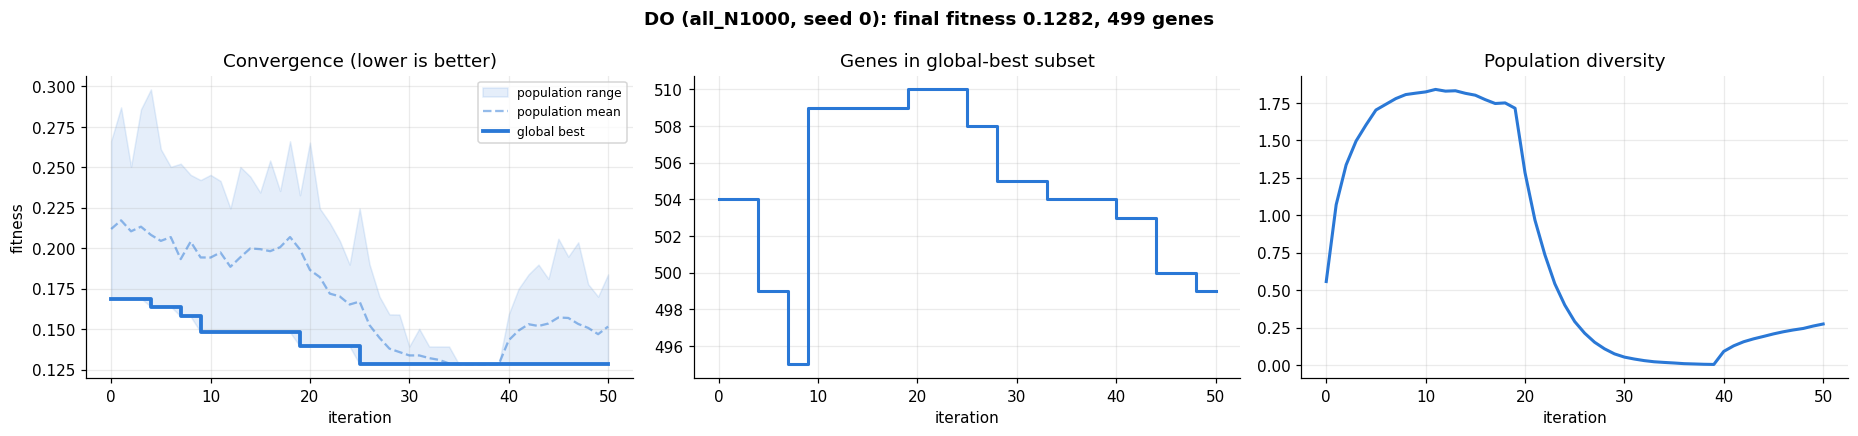

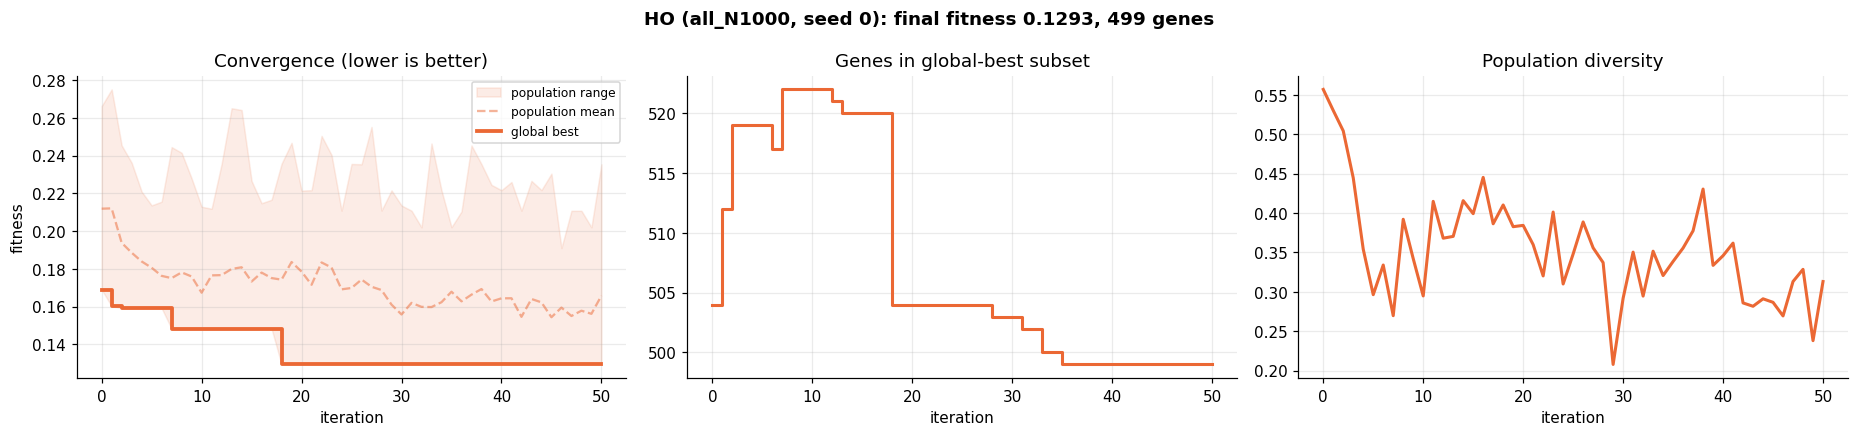

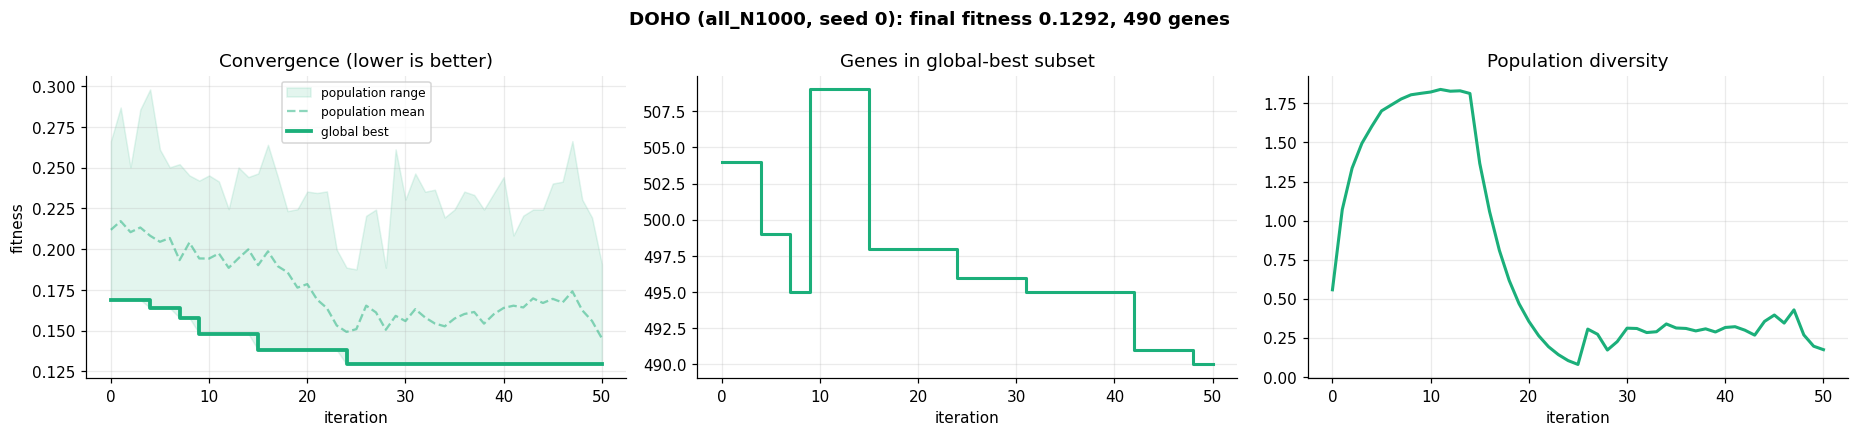

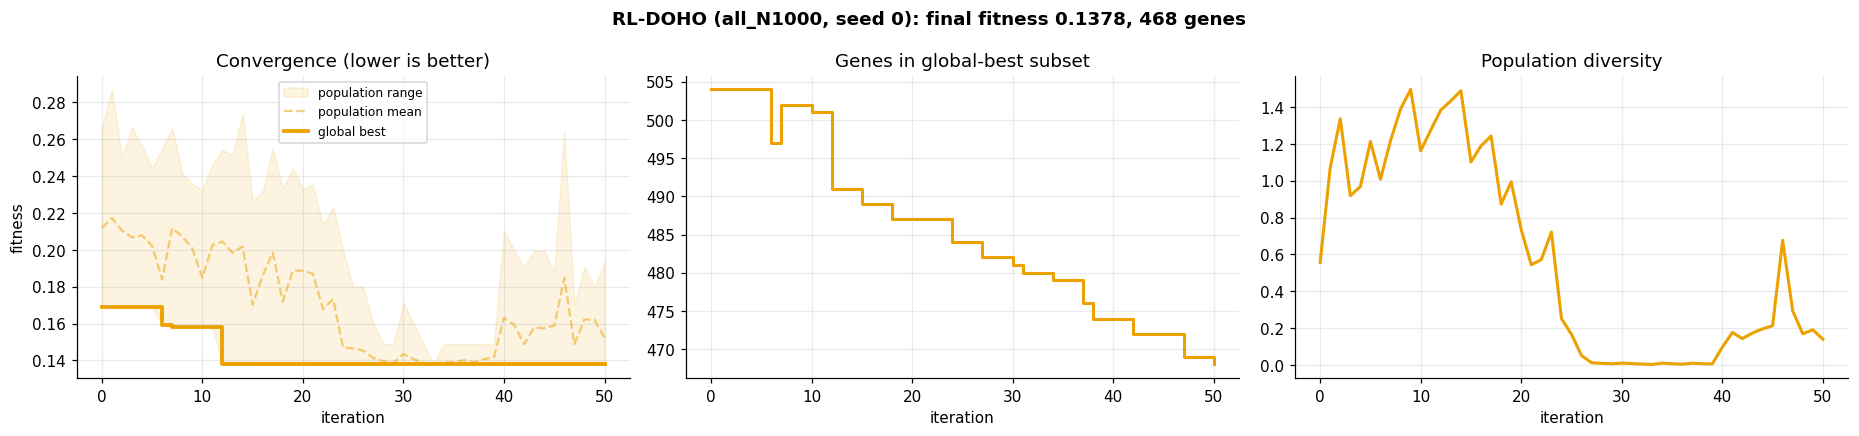

In [10]:
# One figure per algorithm: convergence, genes selected, diversity
def plot_algorithm(a, h, tag=""):
    c = COLORS[a]; x = h["iter"]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(f"{a}{tag}: final fitness {h['best'].iloc[-1]:.4f}, {h['n_feats'].iloc[-1]} genes", fontweight="bold")
    ax[0].fill_between(x, h["gen_best"], h["worst"], color=c, alpha=0.12, label="population range")
    ax[0].plot(x, h["mean"], color=c, alpha=0.5, lw=1.5, ls="--", label="population mean")
    ax[0].step(x, h["best"], where="post", color=c, lw=2.5, label="global best")
    ax[0].set_title("Convergence (lower is better)"); ax[0].set_xlabel("iteration"); ax[0].set_ylabel("fitness"); ax[0].legend(fontsize=8)
    ax[1].step(x, h["n_feats"], where="post", color=c); ax[1].set_title("Genes in global-best subset"); ax[1].set_xlabel("iteration")
    ax[2].plot(x, h["diversity"], color=c); ax[2].set_title("Population diversity"); ax[2].set_xlabel("iteration")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/01_{a}_{DETAIL_DATASET}_s{DETAIL_SEED}.png", bbox_inches="tight"); plt.show()

for a in ALGOS: plot_algorithm(a, detail[a]["hist"], f" ({DETAIL_DATASET}, seed {DETAIL_SEED})")

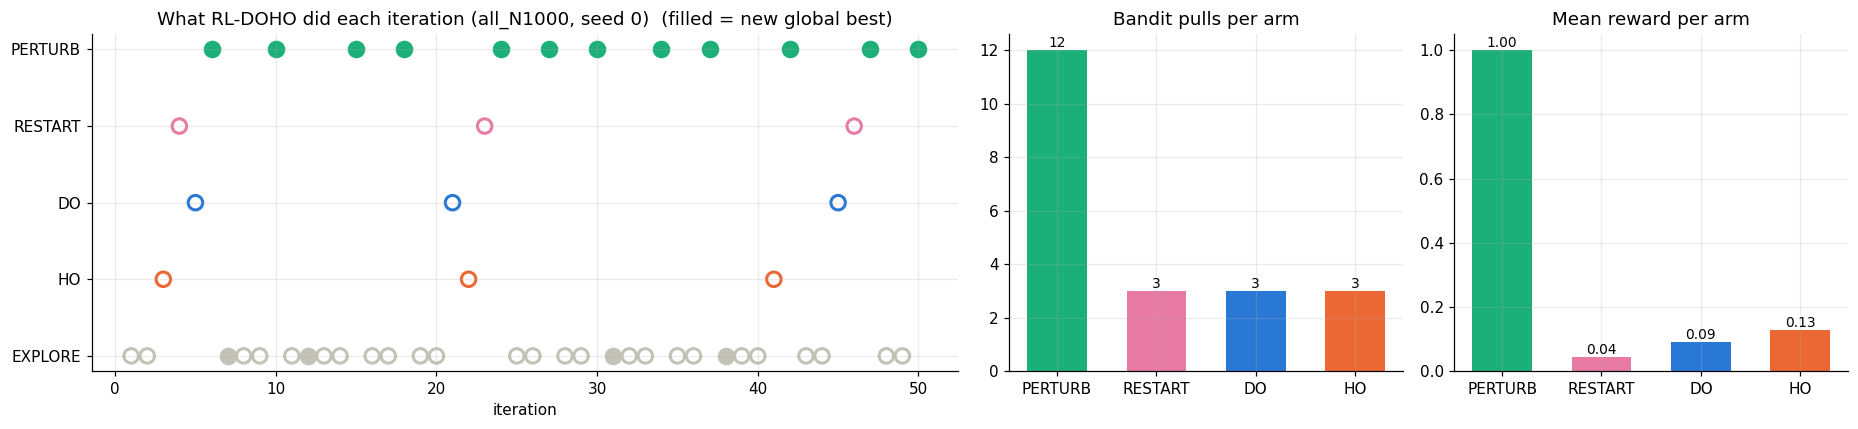

In [11]:
ARM_COL = {"EXPLORE": "#c3c2b7", "PERTURB": "#1baf7a", "RESTART": "#e87ba4", "DO": "#2a78d6", "HO": "#eb6834"}
def plot_ucb(h, tag="", fname="bandit"):
    hh = h.iloc[1:]
    lanes = ["EXPLORE"] + list(h.attrs.get("arm_names", ARMS))[::-1]
    improved = np.r_[False, np.diff(h["best"].values) < 0][1:]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
    for lane_i, lane in enumerate(lanes):
        sel = (hh["arm"] == lane).values
        ax[0].scatter(hh["iter"][sel & ~improved], [lane_i] * int((sel & ~improved).sum()), s=90, color=ARM_COL[lane],
                      marker="o", facecolors="none", linewidths=2)
        ax[0].scatter(hh["iter"][sel & improved], [lane_i] * int((sel & improved).sum()), s=110, color=ARM_COL[lane], marker="o")
    ax[0].set_yticks(range(len(lanes))); ax[0].set_yticklabels(lanes); ax[0].set_xlabel("iteration")
    ax[0].set_title(f"What RL-DOHO did each iteration{tag}  (filled = new global best)")
    arms = list(h.attrs.get("arm_names", ARMS)); pulls = h.attrs["pulls"]; val = h.attrs["arm_value"]
    ax[1].bar(arms, pulls, color=[ARM_COL[a] for a in arms], width=0.6); ax[1].set_title("Bandit pulls per arm")
    for i, v in enumerate(pulls): ax[1].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
    ax[2].bar(arms, val, color=[ARM_COL[a] for a in arms], width=0.6); ax[2].set_title("Mean reward per arm")
    for i, v in enumerate(val): ax[2].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}.png", bbox_inches="tight"); plt.show()

plot_ucb(detail["RL-DOHO"]["hist"], f" ({DETAIL_DATASET}, seed {DETAIL_SEED})", fname=f"02_rl_doho_bandit_{DETAIL_DATASET}")

## 8. Benchmark: 4 datasets × 10 seeds × 4 algorithms (resumable)
Every run is saved as soon as it finishes. If Colab disconnects, run this cell again and it skips finished runs. A dot is printed every 10 new fitness evaluations.

In [12]:
RES_FILE = f"{OUT_DIR}/hd_runs_p{POP_SIZE}_i{MAX_ITER}.pkl"
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
print(f"{len(runs)} runs already done")

def slim(h):  # keep the per-iteration curves, drop the large per-agent masks
    return h.drop(columns=[c for c in ("best_mask", "pop_masks") if c in h.columns])

def record(m, f, h):
    te = evaluate_on_test(m)
    return {"mask": np.packbits(m.astype(np.uint8)), "n": len(m), "fit": f, "cv_acc": _cache[mask_str(m)]["acc"],
            "test_acc": te["acc"], "test_plain_acc": te["plain_acc"], "test_f1": te["f1"], "n_feats": int(m.sum()), "hist": slim(h)}

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [a for a in ALGOS if (ds, a, s) not in runs]
        if not todo: continue
        use_dataset(ds, s)
        if ("ALL", ds, s) not in runs:
            runs[("ALL", ds, s)] = evaluate_on_test(np.ones(N_FEATURES, int))["acc"]
        for a in todo:
            if ds == DETAIL_DATASET and s == DETAIL_SEED and a in detail:
                m, f, h = detail[a]["mask"], detail[a]["fit"], detail[a]["hist"]
            else:
                m, f, h = RUNNERS[a](seed=s, verbose=VERBOSE)
            runs[(ds, a, s)] = record(m, f, h)
            pickle.dump(runs, open(RES_FILE, "wb"))
        save_cache_now()
        print(f"\n[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " + "  ".join(
            f"{a}={runs[(ds, a, s)]['fit']:.4f}/{runs[(ds, a, s)]['test_acc']:.3f}" for a in ALGOS)
            + f"  (fitness/test acc)  elapsed {time.time() - t_start:.0f}s", flush=True)
print("\nBenchmark complete.")

0 runs already done

[18:41:43] all_N200 seed 0: DO=0.1267/0.714  HO=0.1866/0.689  DOHO=0.1168/0.784  RL-DOHO=0.1167/0.784  (fitness/test acc)  elapsed 41s

[18:42:24] all_N200 seed 1: DO=0.1642/0.793  HO=0.1601/0.818  DOHO=0.1753/0.818  RL-DOHO=0.1858/0.793  (fitness/test acc)  elapsed 82s

[18:43:06] all_N200 seed 2: DO=0.1149/0.768  HO=0.0852/0.698  DOHO=0.1148/0.627  RL-DOHO=0.1159/0.677  (fitness/test acc)  elapsed 125s

[18:43:43] all_N200 seed 3: DO=0.1657/0.743  HO=0.1354/0.739  DOHO=0.1657/0.743  RL-DOHO=0.1352/0.764  (fitness/test acc)  elapsed 162s

[18:44:23] all_N200 seed 4: DO=0.1423/0.768  HO=0.1862/0.789  DOHO=0.1535/0.859  RL-DOHO=0.1288/0.909  (fitness/test acc)  elapsed 202s

[18:45:05] all_N200 seed 5: DO=0.1051/0.723  HO=0.1156/0.677  DOHO=0.1248/0.677  RL-DOHO=0.1056/0.702  (fitness/test acc)  elapsed 244s

[18:45:46] all_N200 seed 6: DO=0.1219/0.648  HO=0.1111/0.814  DOHO=0.1063/0.718  RL-DOHO=0.0993/0.764  (fitness/test acc)  elapsed 285s

[18:46:26] all_N200 se

## 9. Results per dataset

In [13]:
summary = pd.DataFrame([{"dataset": ds, "algo": a, "seed": s, **{k: v for k, v in r.items() if k not in ("mask", "hist", "n")}}
                        for (ds, a, s), r in runs.items() if ds != "ALL" and a in ALGOS and s in SEEDS and ds in DATASETS])
summary.to_csv(f"{OUT_DIR}/hd_per_run.csv", index=False)
table = summary.groupby(["dataset", "algo"], sort=False).agg(
    fit_mean=("fit", "mean"), fit_std=("fit", "std"), fit_worst=("fit", "max"),
    cv_acc=("cv_acc", "mean"), test_acc_mean=("test_acc", "mean"), test_acc_std=("test_acc", "std"),
    test_plain_acc=("test_plain_acc", "mean"), test_f1=("test_f1", "mean"), n_probes=("n_feats", "mean"))
allg = pd.Series({ds: np.mean([runs[("ALL", ds, s)] for s in SEEDS]) for ds in DATASETS}, name="all genes test acc")
table.to_csv(f"{OUT_DIR}/hd_summary.csv")
print("Test balanced accuracy using all candidate probes (no selection):"); print(allg.round(4).to_string()); print()
table.round(4)

Test balanced accuracy using all candidate probes (no selection):
all_N200     0.7532
all_N500     0.8068
all_N1000    0.8259
all_N2000    0.8445
all_N5000    0.8532
b1_N200      0.8167
b1_N500      0.8167
b1_N1000     0.8444
b1_N2000     0.8389
b1_N5000     0.8833



fit_mean  fit_std  fit_worst  cv_acc  test_acc_mean  \
dataset   algo                                                           
all_N200  DO         0.1369   0.0200     0.1657  0.8666         0.7659   
          HO         0.1429   0.0369     0.1924  0.8605         0.7725   
          DOHO       0.1370   0.0225     0.1753  0.8665         0.7775   
          RL-DOHO    0.1224   0.0252     0.1858  0.8809         0.7875   
all_N500  DO         0.1328   0.0280     0.1803  0.8708         0.7961   
          HO         0.1389   0.0372     0.2022  0.8646         0.8061   
          DOHO       0.1364   0.0335     0.1912  0.8671         0.8082   
          RL-DOHO    0.1361   0.0391     0.1936  0.8671         0.7655   
all_N1000 DO         0.1273   0.0274     0.1559  0.8763         0.8164   
          HO         0.1292   0.0296     0.1665  0.8743         0.8441   
          DOHO       0.1287   0.0318     0.1754  0.8749         0.8320   
          RL-DOHO    0.1299   0.0296     0.1861  0.8734         0.8495   
all_N2000 DO         0.1251   0.0278     0.1736  0.8785         0.8466   
          HO         0.1236   0.0247     0.1605  0.8801         0.8582   
          DOHO       0.1243   0.0337     0.1847  0.8793         0.8466   
          RL-DOHO    0.1250   0.0269     0.1748  0.8786         0.8470   
all_N5000 DO         0.1276   0.0259     0.1649  0.8761         0.8718   
          HO         0.1299   0.0266     0.1650  0.8737         0.8632   
          DOHO       0.1227   0.0245     0.1649  0.8811         0.8673   
          RL-DOHO    0.1255   0.0258     0.1540  0.8782         0.8673   
b1_N200   DO         0.1139   0.0302     0.1532  0.8895         0.8000   
          HO         0.0966   0.0278     0.1430  0.9070         0.8056   
          DOHO       0.1048   0.0256     0.1378  0.8985         0.8278   
          RL-DOHO    0.1096   0.0283     0.1382  0.8935         0.7722   
b1_N500   DO         0.1343   0.0206     0.1633  0.8690         0.8222   
          HO         0.1282   0.0239     0.1679  0.8750         0.8167   
          DOHO       0.1347   0.0154     0.1528  0.8685         0.8222   
          RL-DOHO    0.1302   0.0214     0.1481  0.8730         0.8444   
b1_N1000  DO         0.1432   0.0275     0.1779  0.8600         0.8278   
          HO         0.1333   0.0264     0.1680  0.8700         0.8500   
          DOHO       0.1406   0.0250     0.1679  0.8625         0.8278   
          RL-DOHO    0.1380   0.0220     0.1725  0.8650         0.8111   
b1_N2000  DO         0.1363   0.0223     0.1729  0.8670         0.8389   
          HO         0.1383   0.0269     0.1728  0.8650         0.8444   
          DOHO       0.1339   0.0195     0.1728  0.8695         0.8611   
          RL-DOHO    0.1402   0.0233     0.1729  0.8630         0.8278   
b1_N5000  DO         0.1290   0.0230     0.1780  0.8745         0.8722   
          HO         0.1290   0.0230     0.1779  0.8745         0.8833   
          DOHO       0.1315   0.0259     0.1780  0.8720         0.8722   
          RL-DOHO    0.1290   0.0258     0.1780  0.8745         0.8667   

                   test_acc_std  test_plain_acc  test_f1  n_probes  
dataset   algo                                                      
all_N200  DO             0.0624          0.7903   0.7678      96.5  
          HO             0.0737          0.7935   0.7724      95.8  
          DOHO           0.0836          0.8000   0.7772      97.4  
          RL-DOHO        0.0710          0.8129   0.7891      89.4  
all_N500  DO             0.0442          0.8161   0.7950     243.0  
          HO             0.0582          0.8290   0.8090     239.8  
          DOHO           0.0354          0.8290   0.8100     242.9  
          RL-DOHO        0.0517          0.7871   0.7646     225.8  
all_N1000 DO             0.0555          0.8290   0.8128     485.2  
          HO             0.0540          0.8516   0.8399     477.5  
          DOHO           0.0382          0.8387   0.8260     484.5  
          RL-

In [14]:
# Statistics per dataset: wins/ties/losses and Wilcoxon, RL-DOHO vs each baseline, plus Friedman
rows = []
for ds in DATASETS:
    F = summary[summary.dataset == ds].pivot(index="seed", columns="algo", values="fit")[ALGOS]
    T = summary[summary.dataset == ds].pivot(index="seed", columns="algo", values="test_acc")[ALGOS]
    try: fr = friedmanchisquare(*[F[a] for a in ALGOS]).pvalue
    except ValueError: fr = np.nan
    print(f"\n=== {ds} ===   Friedman on fitness p={fr:.4f}   average rank: " +
          ", ".join(f"{a}={v:.2f}" for a, v in F.rank(axis=1).mean().items()))
    for b in ALGOS:
        if b == PROPOSED: continue
        d = F[PROPOSED] - F[b]
        try: p = wilcoxon(F[PROPOSED], F[b], zero_method="zsplit").pvalue
        except ValueError: p = np.nan
        dt = T[PROPOSED] - T[b]
        print(f"  {PROPOSED} vs {b:5s} fitness W/T/L={np.sum(d < -1e-12)}/{np.sum(np.abs(d) <= 1e-12)}/{np.sum(d > 1e-12)}  "
              f"p={p:.4f}  | test acc mean diff={dt.mean():+.4f}")
        rows.append({"dataset": ds, "vs": b, "wins": int(np.sum(d < -1e-12)), "ties": int(np.sum(np.abs(d) <= 1e-12)),
                     "losses": int(np.sum(d > 1e-12)), "p": p})
wtl = pd.DataFrame(rows); wtl.to_csv(f"{OUT_DIR}/hd_wins_ties_losses.csv", index=False)
print("\nTotal over all datasets and seeds:")
print(wtl.groupby("vs")[["wins", "ties", "losses"]].sum().to_string())


=== all_N200 ===   Friedman on fitness p=0.1968   average rank: DO=3.00, HO=2.50, DOHO=2.70, RL-DOHO=1.80
  RL-DOHO vs DO    fitness W/T/L=7/0/3  p=0.0645  | test acc mean diff=+0.0216
  RL-DOHO vs HO    fitness W/T/L=7/0/3  p=0.1602  | test acc mean diff=+0.0150
  RL-DOHO vs DOHO  fitness W/T/L=8/0/2  p=0.0273  | test acc mean diff=+0.0100

=== all_N500 ===   Friedman on fitness p=0.7720   average rank: DO=2.20, HO=2.75, DOHO=2.65, RL-DOHO=2.40
  RL-DOHO vs DO    fitness W/T/L=4/0/6  p=0.5566  | test acc mean diff=-0.0307
  RL-DOHO vs HO    fitness W/T/L=6/0/4  p=0.7695  | test acc mean diff=-0.0407
  RL-DOHO vs DOHO  fitness W/T/L=6/0/4  p=0.7695  | test acc mean diff=-0.0427

=== all_N1000 ===   Friedman on fitness p=0.9233   average rank: DO=2.50, HO=2.50, DOHO=2.30, RL-DOHO=2.70
  RL-DOHO vs DO    fitness W/T/L=5/0/5  p=0.7695  | test acc mean diff=+0.0332
  RL-DOHO vs HO    fitness W/T/L=4/0/6  p=0.7695  | test acc mean diff=+0.0055
  RL-DOHO vs DOHO  fitness W/T/L=4/0/6  p=0.62

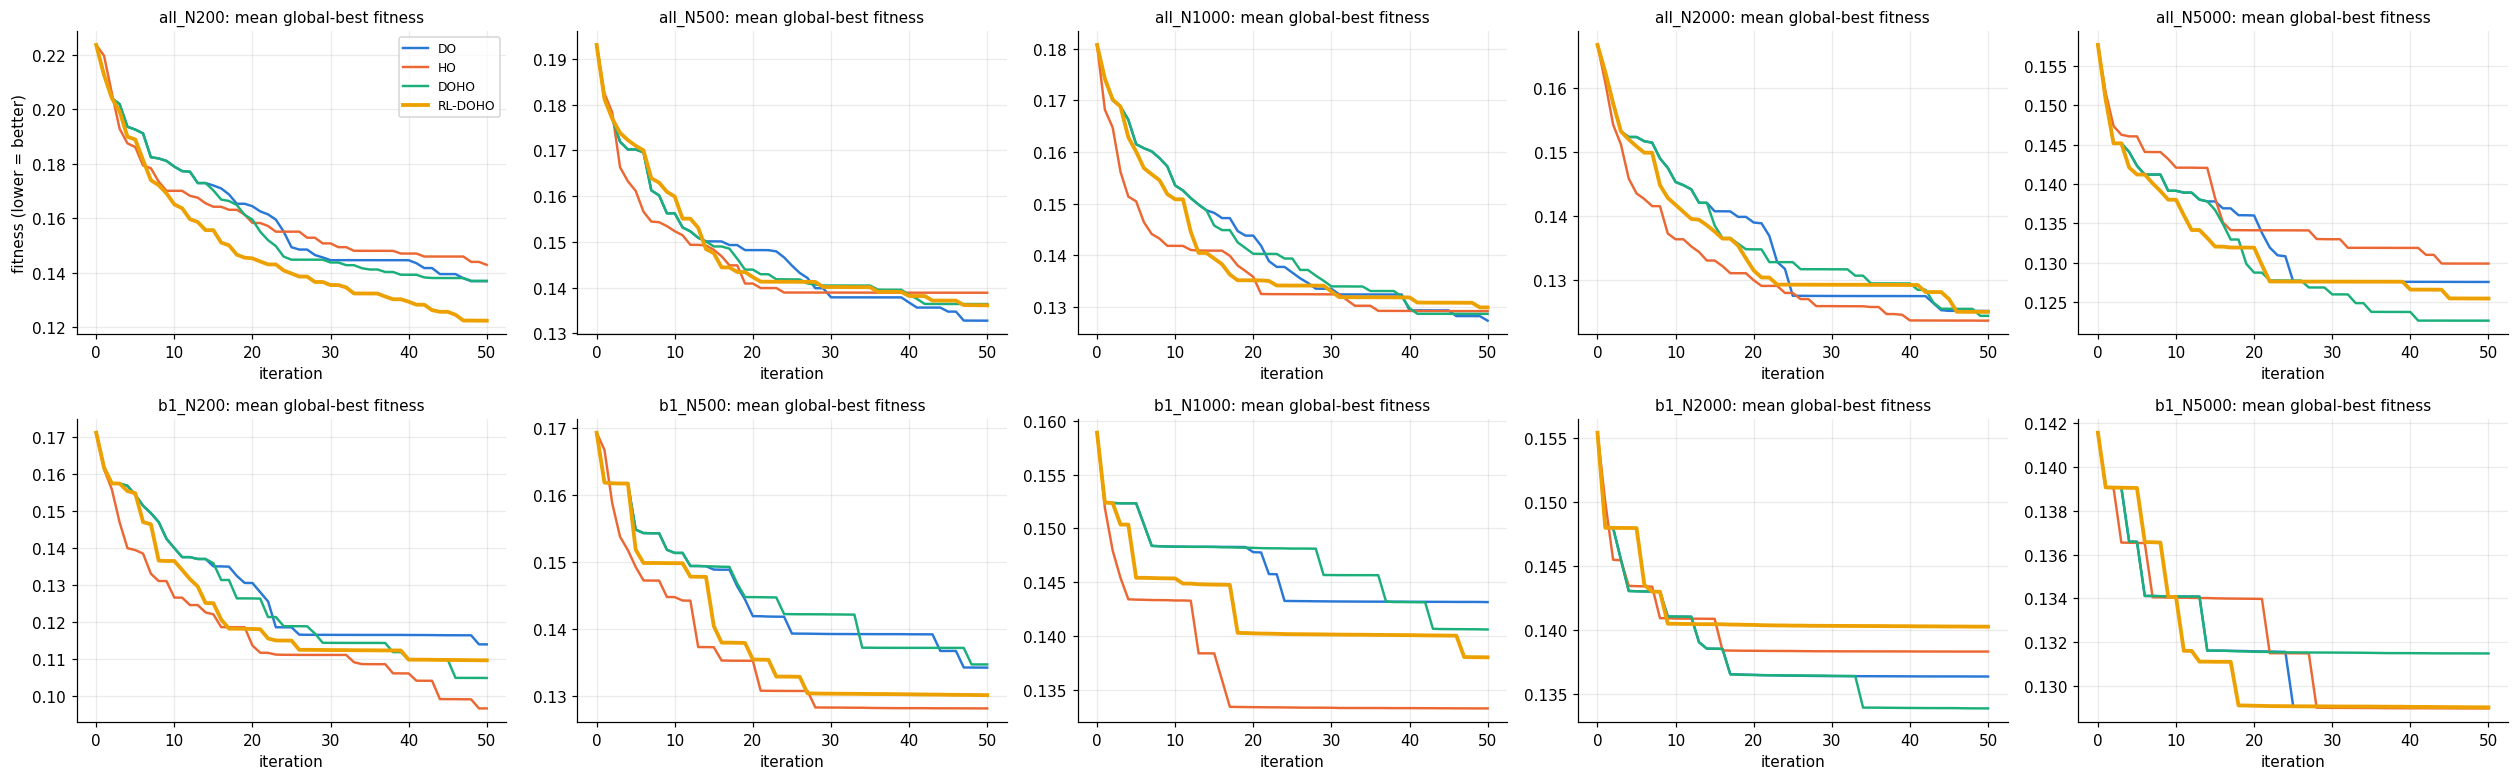

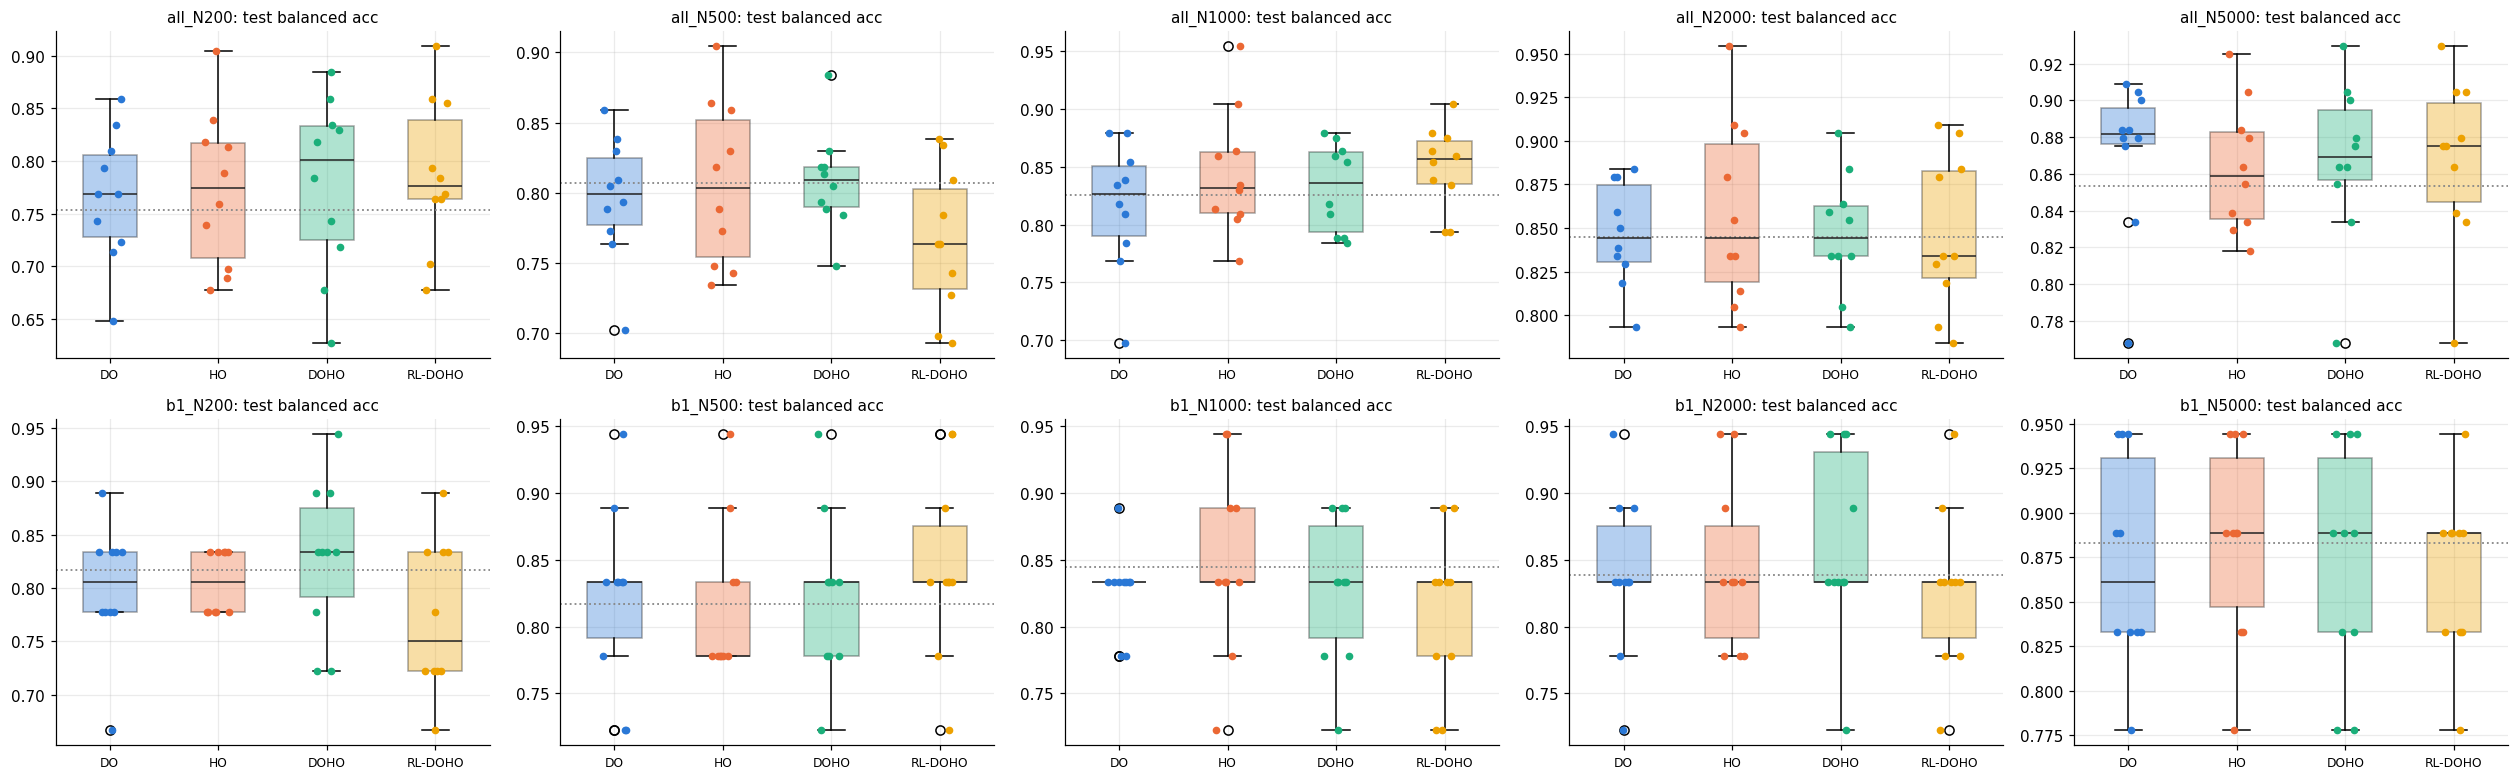

In [15]:
# Mean convergence per setting (rows: all people / batch 1; columns: number of candidate features)
nd = len(DATASETS); ncol = len(SIZES); nrow = int(np.ceil(nd / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.6 * nrow), squeeze=False)
for k, ds in enumerate(DATASETS):
    a_ = ax[k // ncol, k % ncol]
    for a in ALGOS:
        B = np.vstack([runs[(ds, a, s)]["hist"]["best"].values for s in SEEDS])
        a_.plot(B.mean(0), color=COLORS[a], label=a, lw=2.5 if a == PROPOSED else 1.6)
    a_.set_title(f"{ds}: mean global-best fitness", fontsize=10); a_.set_xlabel("iteration")
ax[0, 0].set_ylabel("fitness (lower = better)"); ax[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/03_convergence_per_setting.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.6 * nrow), squeeze=False)
jit = np.random.default_rng(0)
for k, ds in enumerate(DATASETS):
    a_ = ax[k // ncol, k % ncol]
    data = [summary[(summary.dataset == ds) & (summary.algo == a)]["test_acc"].values for a in ALGOS]
    bp = a_.boxplot(data, widths=0.5, patch_artist=True, medianprops=dict(color="#222"))
    for patch, a in zip(bp["boxes"], ALGOS): patch.set_facecolor(COLORS[a]); patch.set_alpha(0.35)
    for i, (d, a) in enumerate(zip(data, ALGOS)):
        a_.scatter(i + 1 + jit.uniform(-0.12, 0.12, len(d)), d, color=COLORS[a], s=16, zorder=3)
    a_.set_xticks(range(1, len(ALGOS) + 1)); a_.set_xticklabels(ALGOS, fontsize=8)
    a_.axhline(allg[ds], color="#888", ls=":", lw=1.2); a_.set_title(f"{ds}: test balanced acc", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/04_test_acc_per_setting.png", bbox_inches="tight"); plt.show()

## 10. Ablation across datasets: which parts of RL-DOHO matter?
In Notebook 1, PERTURB-only was best on a single small dataset. The argument for an adaptive controller is that **no single fixed arm is best on every dataset**. This section tests that directly.


[20:03:03] ablation all_N200 seed 0: RL-DOHO=0.1167  Random arm=0.1256  Without HO arm=0.1255  PERTURB only=0.1639  Q-learning controller=0.1866  No local search=0.1267

[20:03:41] ablation all_N200 seed 1: RL-DOHO=0.1858  Random arm=0.1540  Without HO arm=0.1416  PERTURB only=0.1746  Q-learning controller=0.1957  No local search=0.1642

[20:04:21] ablation all_N200 seed 2: RL-DOHO=0.1159  Random arm=0.1050  Without HO arm=0.1146  PERTURB only=0.1044  Q-learning controller=0.1172  No local search=0.1149

[20:04:58] ablation all_N200 seed 3: RL-DOHO=0.1352  Random arm=0.1559  Without HO arm=0.1458  PERTURB only=0.1460  Q-learning controller=0.1551  No local search=0.1657

[20:05:40] ablation all_N200 seed 4: RL-DOHO=0.1288  Random arm=0.1505  Without HO arm=0.1283  PERTURB only=0.1886  Q-learning controller=0.1508  No local search=0.1423

[20:06:20] ablation all_N200 seed 5: RL-DOHO=0.1056  Random arm=0.0967  Without HO arm=0.1175  PERTURB only=0.1070  Q-learning controller=0.0969  No 

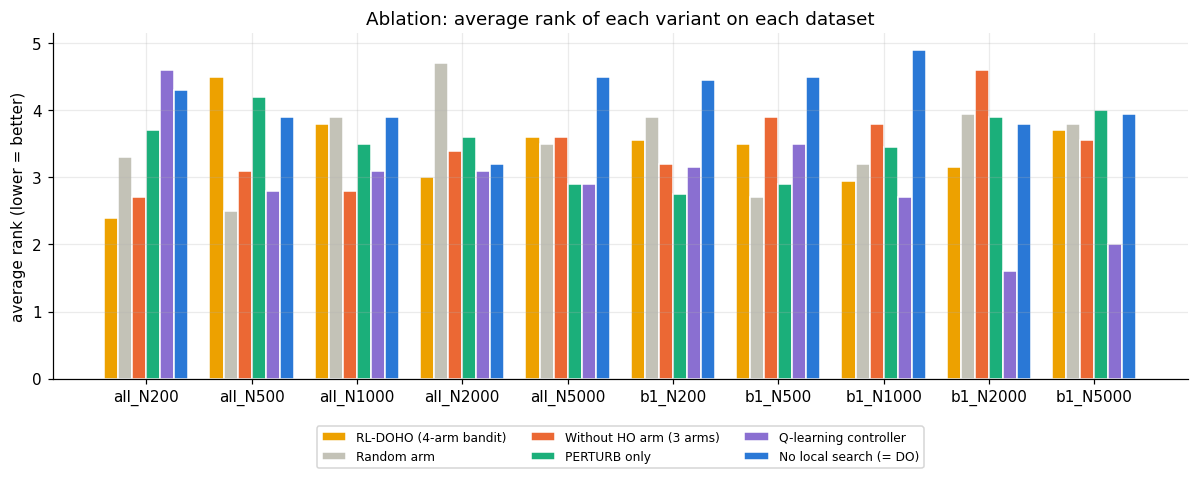

In [16]:
B4 = dict(verbose=VERBOSE)
ABL = {
    "RL-DOHO (4-arm bandit)":  None,
    "Random arm":              lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: RandomArm(n_arms=4, seed=sd), **B4),
    "Without HO arm (3 arms)": lambda s, n: rl_doho(seed=s, name=n, arms=("PERTURB", "RESTART", "DO"), **B4),
    "PERTURB only":            lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: FixedArm(0, sd, n_arms=4), **B4),
    "Q-learning controller":   lambda s, n: rl_doho_qlearning(seed=s, name=n, **B4),
    "No local search (= DO)":  "DO",
}
ABL_NAMES = list(ABL)
ABL_COL = dict(zip(ABL_NAMES, ["#eda100", "#c3c2b7", "#eb6834", "#1baf7a", "#8a6fd1", "#2a78d6"]))

if RUN_ABLATION:
    ABL_FILE = f"{OUT_DIR}/hd_ablation_p{POP_SIZE}_i{MAX_ITER}.pkl"
    abl = pickle.load(open(ABL_FILE, "rb")) if os.path.exists(ABL_FILE) else {}
    for ds in DATASETS:
        for s in SEEDS:
            todo = [n for n in ABL_NAMES if (ds, n, s) not in abl]
            if not todo: continue
            use_dataset(ds, s)
            for n in todo:
                fn = ABL[n]
                if fn is None or fn == "DO":
                    r = runs[(ds, PROPOSED if fn is None else "DO", s)]
                    abl[(ds, n, s)] = {k: r[k] for k in ("fit", "cv_acc", "test_acc", "n_feats")}
                else:
                    m, f, h = fn(s, n); r = record(m, f, h)
                    abl[(ds, n, s)] = {k: r[k] for k in ("fit", "cv_acc", "test_acc", "n_feats")}
                pickle.dump(abl, open(ABL_FILE, "wb"))
            save_cache_now()
            print(f"\n[{time.strftime('%H:%M:%S')}] ablation {ds} seed {s}: " +
                  "  ".join(f"{n.split(' (')[0]}={abl[(ds, n, s)]['fit']:.4f}" for n in ABL_NAMES), flush=True)

    ab = pd.DataFrame([{"dataset": ds, "variant": n, "seed": s, **abl[(ds, n, s)]} for ds in DATASETS for n in ABL_NAMES for s in SEEDS])
    ab.to_csv(f"{OUT_DIR}/hd_ablation.csv", index=False)
    print("\nMean fitness per dataset (lower = better):")
    piv = ab.pivot_table(index="variant", columns="dataset", values="fit", aggfunc="mean").reindex(ABL_NAMES)[DATASETS]
    print(piv.round(4).to_string())
    # rank of each variant within every (dataset, seed), then averaged: the cross-dataset robustness measure
    ab["rank"] = ab.groupby(["dataset", "seed"])["fit"].rank()
    rk = ab.pivot_table(index="variant", columns="dataset", values="rank", aggfunc="mean").reindex(ABL_NAMES)[DATASETS]
    rk["OVERALL"] = ab.groupby("variant")["rank"].mean().reindex(ABL_NAMES)
    print("\nAverage rank (1 = best) per dataset and overall:"); print(rk.round(2).to_string())
    best_per_ds = piv.idxmin()
    print("\nBest variant per dataset:"); print(best_per_ds.to_string())

    print("\nWilcoxon over all datasets × seeds, RL-DOHO vs each variant (fitness):")
    base = ab[ab.variant == ABL_NAMES[0]].sort_values(["dataset", "seed"])["fit"].values
    for n in ABL_NAMES[1:]:
        other = ab[ab.variant == n].sort_values(["dataset", "seed"])["fit"].values
        d = base - other
        try: p = wilcoxon(base, other, zero_method="zsplit").pvalue
        except ValueError: p = np.nan
        print(f"  vs {n:24s} W/T/L={np.sum(d < -1e-12)}/{np.sum(np.abs(d) <= 1e-12)}/{np.sum(d > 1e-12)}  p={p:.4f}")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    w = 0.8 / len(ABL_NAMES); xs = np.arange(len(DATASETS))
    for i, n in enumerate(ABL_NAMES):
        ax.bar(xs + i * w, rk.loc[n, DATASETS].values, width=w, color=ABL_COL[n], label=n, edgecolor="white", lw=1)
    ax.set_xticks(xs + w * (len(ABL_NAMES) - 1) / 2); ax.set_xticklabels(DATASETS)
    ax.set_ylabel("average rank (lower = better)"); ax.set_title("Ablation: average rank of each variant on each dataset")
    ax.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/05_ablation_ranks.png", bbox_inches="tight"); plt.show()

## 11. Overall ranking across all datasets

In [17]:
summary["rank"] = summary.groupby(["dataset", "seed"])["fit"].rank()
overall = summary.groupby("algo").agg(avg_rank=("rank", "mean"), mean_test_acc=("test_acc", "mean"),
                                      mean_genes=("n_feats", "mean")).reindex(ALGOS).sort_values("avg_rank")
print("Average rank over all datasets × seeds (1 = best):"); print(overall.round(3).to_string())
dsr = summary.groupby(["dataset", "algo"])["fit"].mean().unstack()[ALGOS]
try: print(f"\nFriedman across datasets (on mean fitness per dataset): p={friedmanchisquare(*[dsr[a] for a in ALGOS]).pvalue:.4f}")
except ValueError: pass
print(f"\nAll results, figures and CSVs are in: {OUT_DIR}")

Average rank over all datasets × seeds (1 = best):
         avg_rank  mean_test_acc  mean_genes
algo                                        
RL-DOHO     2.265          0.824      821.80
HO          2.460          0.834      829.54
DOHO        2.535          0.834      832.43
DO          2.740          0.826      832.32

Friedman across datasets (on mean fitness per dataset): p=0.9484

All results, figures and CSVs are in: /content/drive/MyDrive/rl_doho_results_ra_sweep


## 12. Where does RL-DOHO work best? Rank vs number of candidate features

Average rank per setting (1 = best):
algo                              DO    HO  DOHO  RL-DOHO
group                    n_top                           
all 101 people           200    3.00  2.50  2.70     1.80
                         500    2.20  2.75  2.65     2.40
                         1000   2.50  2.50  2.30     2.70
                         2000   2.30  2.70  2.70     2.30
                         5000   2.80  2.90  2.25     2.05
batch 1 only (60 people) 200    2.95  2.10  2.45     2.50
                         500    2.80  2.05  3.05     2.10
                         1000   3.30  2.40  2.40     1.90
                         2000   2.95  2.40  2.25     2.40
                         5000   2.60  2.30  2.60     2.50

Best method per setting:
group                     n_top
all 101 people            200      RL-DOHO
                          500           DO
                          1000        DOHO
                          2000          DO
                          5000     RL

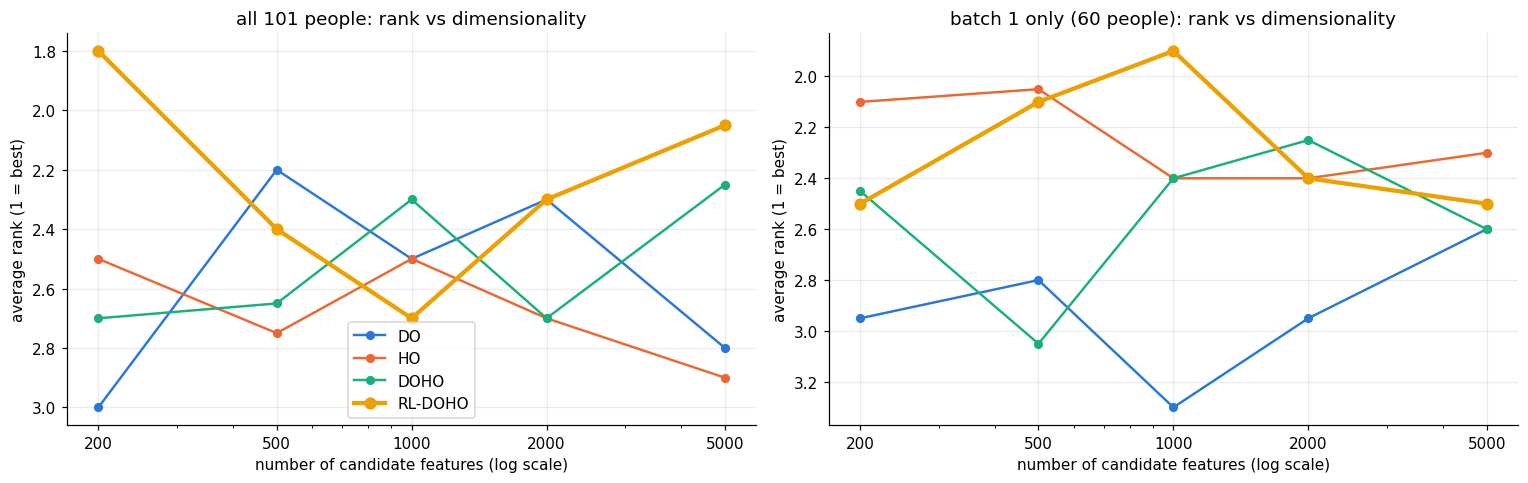

In [18]:
summary["n_top"] = summary.dataset.str.split("_N").str[1].astype(int)
summary["group"] = summary.dataset.str.split("_").str[0].map({"all": "all 101 people", "b1": "batch 1 only (60 people)"})
summary["rank"] = summary.groupby(["dataset", "seed"])["fit"].rank()
rk = summary.groupby(["group", "n_top", "algo"])["rank"].mean().unstack()[ALGOS]
print("Average rank per setting (1 = best):"); print(rk.round(2).to_string())
print("\nBest method per setting:"); print(rk.idxmin(axis=1).to_string())

# RL-DOHO vs the best baseline in each setting (fitness gap; negative = RL-DOHO better)
mf = summary.groupby(["group", "n_top", "algo"])["fit"].mean().unstack()
gap = mf[PROPOSED] - mf[[a for a in ALGOS if a != PROPOSED]].min(axis=1)
print("\nRL-DOHO mean fitness minus best baseline (negative = RL-DOHO better):"); print(gap.round(4).to_string())

groups = list(rk.index.get_level_values(0).unique())
fig, ax = plt.subplots(1, len(groups), figsize=(7 * len(groups), 4.5), squeeze=False); ax = ax[0]
for k, g in enumerate(groups):
    for a in ALGOS:
        ax[k].plot(SIZES, rk.loc[g, a].reindex(SIZES).values, marker="o", color=COLORS[a], label=a,
                   lw=2.8 if a == PROPOSED else 1.6, ms=7 if a == PROPOSED else 5)
    ax[k].set_xscale("log"); ax[k].set_xticks(SIZES); ax[k].set_xticklabels(SIZES)
    ax[k].set_xlabel("number of candidate features (log scale)"); ax[k].set_ylabel("average rank (1 = best)")
    ax[k].invert_yaxis(); ax[k].set_title(f"{g}: rank vs dimensionality")
ax[0].legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/06_rank_vs_dimension.png", bbox_inches="tight"); plt.show()